# Import Libraries

In [54]:
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
import joblib
from timeit import default_timer as timer
print ("libraries were imported successfully...")

libraries were imported successfully...


# Dataset Splitting

In [55]:
house_eng_data = pd.read_csv(r"D:\House_data\raw_data\house_eng_data.csv")
# Selected using: duplicate check (exact match test), relevance check
# (Pearson correlation), overlap check (pairwise correlation + VIF),
# consistency check (variance/frequency test), and holdout R2
# validation (train/test split) confirming distance_to_downtown +
# zip_mean_price preserve the signal lost by dropping lat/long/zipcode.
Features_selected = [
    'sqft_living',
    'sqft_basement',
    'sqft_lot',
    'sqft_living15',
    'sqft_lot15',
    'bedrooms',
    'bathrooms',
    'floors',
    'grade',
    'condition',
    'waterfront',
    'view',
    'house_age',
    'year',
    'yr_renovated_flag',
    'distance_to_downtown',   
    'zip_price_means',  
]
target="price"
house_eng_data.shape


(21600, 53)

In [56]:
# splitting the df into train and test
# engineering the distance to downtown feature for train and test
# engineering the zipcode price mean for train only to prevent leakage of price to test
train,test = train_test_split(house_eng_data,test_size=0.25,random_state=42)
seattle_lat, seattle_long = 47.6062, -122.3321
for df in (train, test):
    df['distance_to_downtown'] = np.sqrt(
        (df['lat'] - seattle_lat) ** 2 + (df['long'] - seattle_long) ** 2
    )
    df.drop(["lat","long"],axis=1,inplace=True,errors='ignore')

# zipcode and price means 
zipcode_price_mean = train.groupby('zipcode')['price'].mean()
general_mean = train['price'].mean()
train['zip_price_means']=train['zipcode'].map(zipcode_price_mean)
test["zip_price_means"]=test['zipcode'].map(zipcode_price_mean).fillna(general_mean)
print ("distance_to_downtown and zip_price_means were created successfully ...")


distance_to_downtown and zip_price_means were created successfully ...


In [57]:
print (train.shape)
print (test.shape)

(16200, 53)
(5400, 53)


In [58]:
X_train,y_train = train[Features_selected],train[target]
print (X_train.shape)
print (y_train.shape)
X_test,y_test = test[Features_selected],test[target]
print (X_test.shape)
print (y_test.shape)

print (X_train.columns)

(16200, 17)
(16200,)
(5400, 17)
(5400,)
Index(['sqft_living', 'sqft_basement', 'sqft_lot', 'sqft_living15',
       'sqft_lot15', 'bedrooms', 'bathrooms', 'floors', 'grade', 'condition',
       'waterfront', 'view', 'house_age', 'year', 'yr_renovated_flag',
       'distance_to_downtown', 'zip_price_means'],
      dtype='str')


In [59]:
# house_eng_data['price_category'] = pd.qcut(house_eng_data['price'], q=4, labels=['low', 'medium1','medium2','high'])
# house_eng_data['price_category'] = house_eng_data['price_category'].astype('category')
# house_eng_data.groupby("price_category")['price'].median()\
#     .reset_index()\
#     .sort_values(by='price_category', ascending=True)\
#     # .rename(columns={'index': 'price_category', 'price_category': 'count'})
# house_eng_data['price_category']=house_eng_data['price_category'].cat.codes
# house_eng_data['price_category'].value_counts()

# Unsupervised K-mean classifier

In [60]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("dim_reduction", PCA(n_components=3)),
    ("classifier", KMeans(n_clusters=4, random_state=42))
])

best_inertia=[]
for i in range(1,11):
    pipeline.set_params(classifier__n_clusters= i)
    pipeline.fit(X_train)
    best_inertia.append(pipeline.named_steps["classifier"].inertia_)
best_inertia



[135261.51672128076,
 90282.89605550424,
 71108.27661936477,
 54464.315287827165,
 44250.56838247075,
 38228.430953524585,
 34586.24032177082,
 31705.704695858953,
 29711.559255556083,
 27711.530514403457]

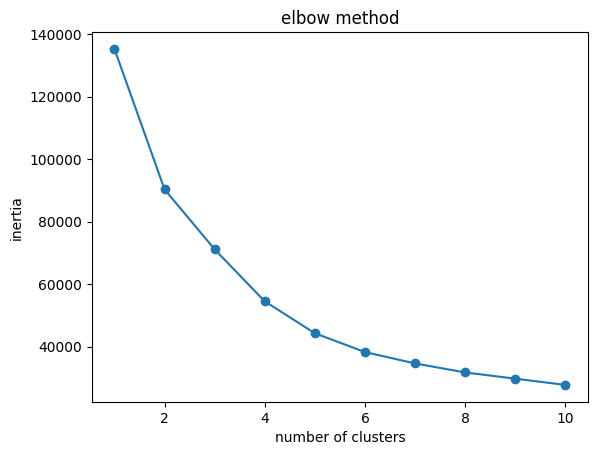

In [61]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),best_inertia,marker='o')
plt.title("elbow method")
plt.xlabel("number of clusters")
plt.ylabel("inertia")
plt.show()

In [62]:
pipeline.set_params(classifier__n_clusters= 4)
pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('dim_reduction', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'

In [63]:
labels = pipeline.named_steps['classifier'].labels_
print(labels)

[1 2 0 ... 3 1 1]


In [64]:
joblib.dump(pipeline,r"D:\House_data\models\unsupervised_KMean.joblib")

['D:\\House_data\\models\\unsupervised_KMean.joblib']

In [65]:
# dir(pipeline.named_steps['classifier'])

In [66]:
prediction = pipeline.predict(X_test)
inertia = pipeline.named_steps['classifier'].inertia_
print (inertia)

54464.315287827165


In [67]:
print (f"{float(inertia):.2f}")

54464.32


In [68]:
# attaching the cluster labels to the original dataset - X_train
X_train_clustered = X_train.copy()
X_train_clustered['cluster_labels'] = pipeline.named_steps['classifier'].labels_  
X_train_clustered.head()

,sqft_living,sqft_basement,sqft_lot,sqft_living15,sqft_lot15,bedrooms,bathrooms,floors,grade,condition,waterfront,view,house_age,year,yr_renovated_flag,distance_to_downtown,zip_price_means,cluster_labels
13480,1520,380,11067,1280,11371,3,2.00,1.0,7,3,0,0,31,2014,0,0.300263,671782.911043,1
15376,2770,0,9350,2660,9695,3,2.50,2.0,8,3,0,3,57,2014,1,0.154052,418585.705696,2
2358,2020,0,6236,1940,5076,4,2.50,2.0,7,3,0,0,12,2014,0,0.337505,283753.325758,0
6409,1840,0,10500,1840,7374,3,2.25,2.0,7,3,0,0,21,2014,0,0.160002,515021.369077,0
937,2020,710,6564,1710,5151,3,2.50,1.0,7,3,0,0,20,2014,0,0.306045,311611.277512,1


In [69]:
X_train_clustered.groupby('cluster_labels').mean()

,sqft_living,sqft_basement,sqft_lot,sqft_living15,sqft_lot15,bedrooms,bathrooms,floors,grade,condition,waterfront,view,house_age,year,yr_renovated_flag,distance_to_downtown,zip_price_means
cluster_labels,,,,,,,,,,,,,,,,,
0,2284.457230,89.149248,10284.625268,2182.620437,9446.059234,3.501074,2.522325,1.972441,8.147996,3.093236,0.000000,0.058518,16.741410,2014.321045,0.005727,0.251348,514976.486166
1,1526.953035,262.111685,9552.857844,1597.673886,8716.681818,3.028960,1.569661,1.138504,6.907706,3.587635,0.001511,0.101486,61.758499,2014.336313,0.043566,0.170890,491834.987948
2,3341.754822,842.536219,16059.451350,2748.419203,13349.948564,4.219460,2.939241,1.571367,8.926704,3.572653,0.044578,1.038148,45.882983,2014.291470,0.116588,0.155375,760998.716814
3,2799.534125,309.272997,223887.905045,2418.089021,159492.750742,3.373887,2.441395,1.519288,8.124629,3.326409,0.008902,0.516320,31.554896,2014.344214,0.038576,0.404014,461236.162299


In [70]:
X_train_clustered.groupby('cluster_labels').median()

,sqft_living,sqft_basement,sqft_lot,sqft_living15,sqft_lot15,bedrooms,bathrooms,floors,grade,condition,waterfront,view,house_age,year,yr_renovated_flag,distance_to_downtown,zip_price_means
cluster_labels,,,,,,,,,,,,,,,,,
0,2240.0,0.0,6705.0,2150.0,6720.0,3.0,2.50,2.0,8.0,3.0,0.0,0.0,14.0,2014.0,0.0,0.261186,505251.829545
1,1490.0,0.0,7522.5,1560.0,7560.0,3.0,1.75,1.0,7.0,3.0,0.0,0.0,60.0,2014.0,0.0,0.146745,460971.182796
2,3130.0,910.0,10125.0,2620.0,9750.0,4.0,2.75,2.0,9.0,3.0,0.0,0.0,44.0,2014.0,0.0,0.137111,671782.911043
3,2600.0,0.0,209199.0,2310.0,156816.0,3.0,2.50,1.5,8.0,3.0,0.0,0.0,26.0,2014.0,0.0,0.389111,429269.708333


In [72]:
X_train_clustered.groupby("cluster_labels")[X_train_clustered.columns].mean()

,sqft_living,sqft_basement,sqft_lot,sqft_living15,sqft_lot15,bedrooms,bathrooms,floors,grade,condition,waterfront,view,house_age,year,yr_renovated_flag,distance_to_downtown,zip_price_means,cluster_labels
cluster_labels,,,,,,,,,,,,,,,,,,
0,2284.457230,89.149248,10284.625268,2182.620437,9446.059234,3.501074,2.522325,1.972441,8.147996,3.093236,0.000000,0.058518,16.741410,2014.321045,0.005727,0.251348,514976.486166,0.0
1,1526.953035,262.111685,9552.857844,1597.673886,8716.681818,3.028960,1.569661,1.138504,6.907706,3.587635,0.001511,0.101486,61.758499,2014.336313,0.043566,0.170890,491834.987948,1.0
2,3341.754822,842.536219,16059.451350,2748.419203,13349.948564,4.219460,2.939241,1.571367,8.926704,3.572653,0.044578,1.038148,45.882983,2014.291470,0.116588,0.155375,760998.716814,2.0
3,2799.534125,309.272997,223887.905045,2418.089021,159492.750742,3.373887,2.441395,1.519288,8.124629,3.326409,0.008902,0.516320,31.554896,2014.344214,0.038576,0.404014,461236.162299,3.0


In [81]:
cluster_labels=X_train_clustered.groupby('cluster_labels')[["bedrooms","bathrooms","sqft_living","sqft_lot","floors"]].agg(["mean","median"])
cluster_labels 

bedrooms        bathrooms         sqft_living          \
                    mean median      mean median         mean  median   
cluster_labels                                                          
0               3.501074    3.0  2.522325   2.50  2284.457230  2240.0   
1               3.028960    3.0  1.569661   1.75  1526.953035  1490.0   
2               4.219460    4.0  2.939241   2.75  3341.754822  3130.0   
3               3.373887    3.0  2.441395   2.50  2799.534125  2600.0   

                     sqft_lot              floors         
                         mean    median      mean median  
cluster_labels                                            
0                10284.625268    6705.0  1.972441    2.0  
1                 9552.857844    7522.5  1.138504    1.0  
2                16059.451350   10125.0  1.571367    2.0  
3               223887.905045  209199.0  1.519288    1.5

In [82]:
cluster_lab = {
    0: "Spacious Single-Story Homes",
    1: "Large / Luxury Estates",
    2: "Compact Starter Homes",
    3: "Multi-Story Family Homes"
}
cluster_labels.index = cluster_labels.index.map(cluster_lab)
cluster_labels

cluster_labels


bedrooms        bathrooms         sqft_living  \
                                 mean median      mean median         mean   
cluster_labels                                                               
Spacious Single-Story Homes  3.501074    3.0  2.522325   2.50  2284.457230   
Large / Luxury Estates       3.028960    3.0  1.569661   1.75  1526.953035   
Compact Starter Homes        4.219460    4.0  2.939241   2.75  3341.754822   
Multi-Story Family Homes     3.373887    3.0  2.441395   2.50  2799.534125   

                                          sqft_lot              floors         
                             median           mean    median      mean median  
cluster_labels                                                                 
Spacious Single-Story Homes  2240.0   10284.625268    6705.0  1.972441    2.0  
Large / Luxury Estates       1490.0    9552.857844    7522.5  1.138504    1.0  
Compact Starter Homes        3130.0   16059.451350   10125.0  1.571367    2.0  
Multi-Story Family Homes     2600.0  223887.905045  209199.0  1.519288    1.5

# Supervised RandomForesetRegressor Regression

In [6]:
# train and test 
print (f"train:\n X_train: {X_train.shape}, y_train: {y_train.shape}")
print (f"test:\n X_test: {X_test.shape}, y_test: {y_test.shape}")

train:
 X_train: (16200, 17), y_train: (16200,)
test:
 X_test: (5400, 17), y_test: (5400,)


In [14]:
#Pipeline 

rf_reg = Pipeline([("scaler",StandardScaler()),
                  ("randomforest",RandomForestRegressor(random_state=42))])
cv = KFold(n_splits=5,shuffle=True,random_state=42)
param_grid = {
    'randomforest__n_estimators':[50,100,200],
    'randomforest__min_samples_leaf':[1,2,3,4],
    'randomforest__max_depth': [None, 10, 20],
    'randomforest__max_features': [1.0,'sqrt']
}
grid_search =GridSearchCV(
    estimator=rf_reg,
    param_grid= param_grid,
    cv = cv,
    scoring='r2',
    verbose=2,
    n_jobs = -1
)


In [44]:
start = timer
print ("timer started...")
# grid_search.fit(X_train,y_train)
end = timer
# duration = end - start
# print (f"duration = {duration}")

timer started...


In [46]:
start

<function time.perf_counter()>

In [20]:
dir(grid_search)

['__abstractmethods__',
 '__annotate_func__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_check_refit_for_multimetric',
 '_check_scorers_accept_sample_weight',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_format_results',
 '_get_class_level_metadata_request_values',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_get_routed_params_for_fit',
 '_get_scorers',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle

In [21]:
# best parameters and score
print (f"best parameters: {grid_search.best_params_}")
print (f"best R2 score: {grid_search.best_score_}")

best parameters: {'randomforest__max_depth': 20, 'randomforest__max_features': 'sqrt', 'randomforest__min_samples_leaf': 1, 'randomforest__n_estimators': 200}
best R2 score: 0.8739160306519068


In [22]:
# prediction
pred = grid_search.predict(X_test)
print ()

[ 669108.46764467  374327.16570626  371272.49683065 ...  332713.70350406
  712144.61002431 1044812.98846154]


accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [33]:
# Metrics
r2 = r2_score(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)

print(f"R2: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")

R2: 0.88
RMSE: 129004.23
MSE: 16642092580.15
MAE: 70423.13
